<i>École Polytechnique de Montréal</i>
<br>
<i>Cours MTH2210A : Calcul scientifique pour ingénieurs</i>
<br>
<i>Session d'été court 2026</i>

<h1><center>Laboratoire 1</center></h1>

| Nelea Robert      | Mifdal Mohamed Reda |
|-------------------|---------------------|
| Matricule 2449901 | Matricule 2362498   |

# Initialisation du notebook

In [2]:
# Réinitialisation complète de l'environnement
%reset -f

# Import des bibliothèques requises
import numpy as np
import matplotlib.pyplot as plt
import sys
from math import sqrt, factorial, pi, e, floor, log10
from scipy.special import erf

# Pré-définition de la fonction "random entre 0 et 1" avec un nom similaire à MatLab
rand = np.random.random

Lien vers un tableau de conversion des commandes MatLab vers Python : https://cheatsheets.quantecon.org/

L'équivalent des opérateurs ./ et .^ sont donnés dans ce guide.

Pensez à supprimer cette cellule de texte au moment de rendre votre rapport de laboratoire !

# Exercice 1

In [3]:
# Calculs
err = np.array([0.5671, 0.4328, 0.4555e-1, 0.3305e-2, 0.2707e-4, 0.1660e-7])
a = (1 + sqrt(5)) / 2

r1 = np.abs(err[1:] / err[:-1])
r2 = np.abs(err[1:] / (err[:-1]**a))
r3 = np.abs(err[1:] / (err[:-1]**2))

tableau = np.column_stack([r1, r2, r3])


In [4]:
# Mise en page des résultats

# print(f"{'Ratio 1':>15} {'Ratio 2':>15} {'Ratio 3':>15}")
# print("-" * 60)
# print(tableau)

print("Tableau 1.1 : Ratios d'erreurs\n")
print("     e(n+1)/e(n)     e(n+1)/e(n)^a    e(n+1)/e(n)^2")
print("-"*60)
np.savetxt(sys.stdout, tableau, fmt='%15.4f')

Tableau 1.1 : Ratios d'erreurs

     e(n+1)/e(n)     e(n+1)/e(n)^a    e(n+1)/e(n)^2
------------------------------------------------------------
         0.7632          1.0836          1.3458
         0.1052          0.1766          0.2432
         0.0726          0.4895          1.5929
         0.0082          0.2796          2.4783
         0.0006          0.4078         22.6533


# Exercice 2

In [5]:
# Calculs
initial = np.arange(1,13+1)
# (a)
fact = np.array([factorial(n) for n in initial])
# (b)
stirling = np.array([sqrt(2*pi*n)*(n/e)**n for n in initial])
# (c)
errAbs = abs(fact - stirling)
errRel = errAbs/fact

tableau = np.column_stack([initial, errAbs, errRel])

In [6]:
# Affichage des graphes
# print(initial)
# print("(a) vecteur factoriel :")
# print(fact)
# print("(b) vecteur stirling :")
# print(stirling)
# print("(c) vecteur d'erreur absolue |n! - Sn| et d'erreur relative |n! - Sn|/n! :")
# print(errAbs)
# print(errRel)

print("Tableau 1.2 : Erreur absolue et relative sur l'esitmation du factoriel de Stirling\n")
print("          n         |n! - Sn|       |n! - Sn|/n!")
print("-"*60)
np.savetxt(sys.stdout, tableau, fmt='%15.0f %15.4e %15.4e')

Tableau 1.2 : Erreur absolue et relative sur l'esitmation du factoriel de Stirling

          n         |n! - Sn|       |n! - Sn|/n!
------------------------------------------------------------
              1      7.7863e-02      7.7863e-02
              2      8.0996e-02      4.0498e-02
              3      1.6379e-01      2.7298e-02
              4      4.9382e-01      2.0576e-02
              5      1.9808e+00      1.6507e-02
              6      9.9218e+00      1.3780e-02
              7      5.9604e+01      1.1826e-02
              8      4.1760e+02      1.0357e-02
              9      3.3431e+03      9.2128e-03
             10      3.0104e+04      8.2960e-03
             11      3.0117e+05      7.5451e-03
             12      3.3141e+06      6.9188e-03
             13      3.9781e+07      6.3885e-03


Discussion des résultats.

L'erreur relative est plus parlante que l'erreur absolue car elle dépend directement de la grandeur de n puisqu'il s'agit d'une division.

# Exercice 3

In [7]:
# Calculs
tol = 0.5e-3

F = []
F.append(1)
F.append(2)
F.append(F[0] + F[1])

alpha = (1 + sqrt(5))/2

err = abs(F[2]/F[1] - alpha)

n = 3
while err > tol:
    F.append(F[n-1] + F[n-2])
    err = abs(F[n]/F[n-1] - alpha)
    n += 1

In [8]:
# Affichage des graphes
print(f"Le nombre n est : {n}")

Le nombre n est : 9


Discussion des résultats.

# Exercice 4

In [9]:
# Calculs

# (a)
def Cd(Re):
    if Re < 0.1:
        return 24/Re
    elif Re >= 0.1 and Re < 800:
        return 24/Re * (1 + 0.15*Re**0.687)
    elif Re >= 800:
        return 0.44

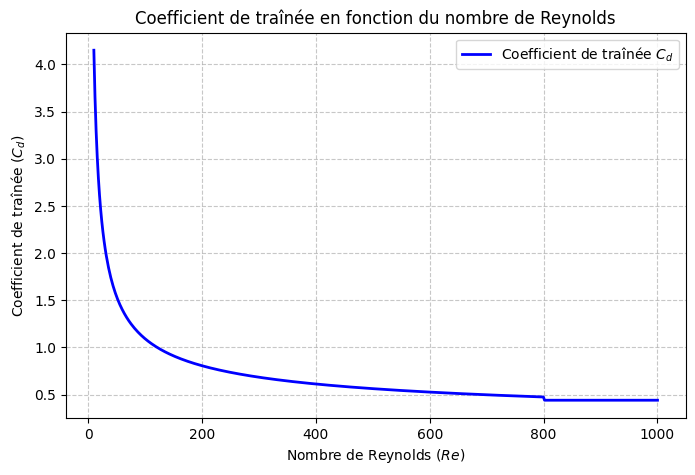

In [10]:
# Résultats

# 1. Créer un tableau de valeurs pour le nombre de Reynolds (Re) entre 10 et 1000
# On utilise 500 points pour s'assurer que la courbe soit bien lisse
Re_valeurs = np.linspace(10, 1000, 500)

# 2. Calculer les valeurs de Cd correspondantes
# On boucle sur chaque valeur de Re pour la passer dans votre fonction Cd(Re)
Cd_valeurs = [Cd(re) for re in Re_valeurs]

# 3. Créer et configurer le graphe
plt.figure(figsize=(8, 5))
plt.plot(Re_valeurs, Cd_valeurs, label='Coefficient de traînée $C_d$', color='blue', linewidth=2)

# 4. Ajouter les labels, le titre et la grille pour un rendu scientifique
plt.xlabel('Nombre de Reynolds ($Re$)')
plt.ylabel('Coefficient de traînée ($C_d$)')
plt.title('Coefficient de traînée en fonction du nombre de Reynolds')
plt.grid(True, linestyle='--', alpha=0.7)
plt.legend()

# 5. Afficher le graphe
plt.show()



# Exercice 5

In [11]:
# a)
def P7erf(x):
    return 2/sqrt(pi) * (x - x**3/3 + x**5/10 - x**7/42)

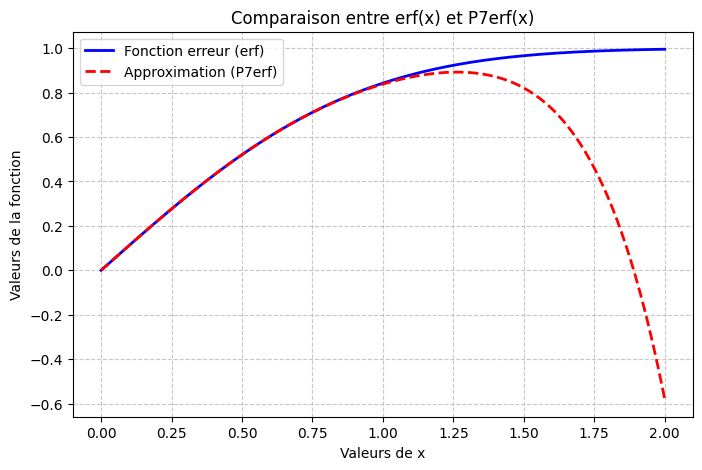

In [12]:
# b)
val = np.linspace(0,2,500)
erfval = erf(val)
P7erfVal = P7erf(val)

plt.figure(figsize=(8, 5))
plt.plot(val, erfval, label='Fonction erreur (erf)', color='blue', linewidth=2)
plt.plot(val, P7erfVal, label='Approximation (P7erf)', color='red', linestyle='--', linewidth=2)

plt.xlabel('Valeurs de x')
plt.ylabel('Valeurs de la fonction')
plt.title('Comparaison entre erf(x) et P7erf(x)')
plt.grid(True, linestyle='--', alpha=0.7)

plt.legend()
plt.show()

L'approximation P7(x) est très précise près de l'origine x0 = 0, mais elle diverge de la véritable fonction erf(x) plus que x augemente. Ce phénomène s'explique car le développement de Taylor est une approximation local.

In [13]:
# c)
x = np.array([1/2, 1/4, 1/8, 1/16, 1/32])
erfX = np.array(erf(x))
P7erfX = np.array(P7erf(x))
tableau1 = np.column_stack([x, erfX, P7erfX])

errAbs = np.array(abs(erfX - P7erfX))
ratio = np.array(errAbs[:-1]/errAbs[1:])
tableau2 = np.column_stack([x[1:], ratio])

print("Tableau 1.5.1 : erf(x) et l'estimation P7erf(x) pour certain points\n")
print("          x          erf(x)        P7erf(x)")
print("-"*60)
np.savetxt(sys.stdout, tableau1, fmt='%15.4f %15.4e %15.4e')

print("\n\nTableau 1.5.2 : Ratio des erreur sur l'estimation P7erf(x) pour certain points\n")
print("          x          Ratio")
print("-"*40)
np.savetxt(sys.stdout, tableau2, fmt='%15.4f %15.4e')

Tableau 1.5.1 : erf(x) et l'estimation P7erf(x) pour certain points

          x          erf(x)        P7erf(x)
------------------------------------------------------------
         0.5000      5.2050e-01      5.2049e-01
         0.2500      2.7633e-01      2.7633e-01
         0.1250      1.4032e-01      1.4032e-01
         0.0625      7.0432e-02      7.0432e-02
         0.0312      3.5250e-02      3.5250e-02


Tableau 1.5.2 : Ratio des erreur sur l'estimation P7erf(x) pour certain points

          x          Ratio
----------------------------------------
         0.2500      4.9681e+02
         0.1250      5.0811e+02
         0.0625      5.1104e+02
         0.0312      4.9764e+02


???  Déduire
de ces résultats l’ordre de précision du polynôme de Taylor de degré 7. JE vais completer plus tard

# Exercice 6

In [18]:
# a)
n = np.arange(2,30+1)
p = [2*sqrt(2)]
for i in n[:-1]:
    p.append(2**i * sqrt(2 * (1 - sqrt(1 - (p[-1]/2**i)**2))))

p = np.array(p)
errAbs = np.array(abs(p-pi))

tableau = np.column_stack([n, p, errAbs])

print(f"Tableau 1.6.1 : Estimation de pi par polygones (pi = {pi})\n")
print("          n               Pn       |Pn - pi|")
print("-"*60)
np.savetxt(sys.stdout, tableau, fmt='%15.0f %15.10f %15.4e')

Tableau 1.6.1 : Estimation de pi par polygones (pi = 3.141592653589793)

          n               Pn       |Pn - pi|
------------------------------------------------------------
              2    2.8284271247      3.1317e-01
              3    3.0614674589      8.0125e-02
              4    3.1214451523      2.0148e-02
              5    3.1365484905      5.0442e-03
              6    3.1403311570      1.2615e-03
              7    3.1412772509      3.1540e-04
              8    3.1415138011      7.8852e-05
              9    3.1415729404      1.9713e-05
             10    3.1415877253      4.9283e-06
             11    3.1415914215      1.2321e-06
             12    3.1415923456      3.0798e-07
             13    3.1415925765      7.7045e-08
             14    3.1415926335      2.0127e-08
             15    3.1415926548      1.2178e-09
             16    3.1415926453      8.2686e-09
             17    3.1415926074      4.6214e-08
             18    3.1415929109      2.5735e-07
     

In [15]:
# b)
# Find the index where n == 15

def CS(errAbs):
    n = floor(log10(errAbs))
    if errAbs >= 5*10**n:
        return abs(n+1)
    else:
        return abs(n)

print(f"P15 a {CS(tableau[15 - 2][2])} chiffre significatif et P24 a {CS(tableau[24 - 2][2])} chiffre significatif.")

P15 a 9 chiffre significatif et P24 a 3 chiffre significatif.


(c) On remarque que l'efficaciter de l'estimation peak a 15 (9 chiffre significatif) et ensuite continue a dégringoler jusqu'à briser complétement avec Pn=4 pour n=29 et Pn=0 pour n=30. Ce phénomène est causer pas les limitation des nombre flotant. Plus que n itère plus que le programme effectue une addition de nombres tres éloignés ou une soustration de nombres très rapprochés, ce qui induit des erreurs qui s'accumulent après n=15.

# Exercice 7

In [16]:
# a)

n = np.array([50, 500, 5000, 50000, 500000])
piAprox = []


for i in n:
    cordArray = []
    nInCircle = 0

    for k in range(i):
        x = rand()*2 - 1
        y = rand()*2 - 1

        if sqrt(x**2 + y**2) <= 1:
            nInCircle += 1

    piAprox.append(4 * nInCircle / i)

piAprox = np.array(piAprox)
errAbs = abs(piAprox - pi)

tableau = np.column_stack([n, piAprox, errAbs])

print(f"Tableau 1.6.1 : Estimation de pi par probabilité (pi = {pi})\n")
print("          n               pi*       |pi - pi*|")
print("-"*60)
np.savetxt(sys.stdout, tableau, fmt='%15.0f %15.10f %15.4e')


Tableau 1.6.1 : Estimation de pi par probabilité (pi = 3.141592653589793)

          n               pi*       |pi - pi*|
------------------------------------------------------------
             50    3.2000000000      5.8407e-02
            500    3.1120000000      2.9593e-02
           5000    3.1592000000      1.7607e-02
          50000    3.1467200000      5.1273e-03
         500000    3.1416480000      5.5346e-05


b) Cette algorithme n'est pas satisfaisant car à chaque n*100 on gagne à peut près 1 chiffre significatif. La dernière méthode par polygones était beaucoup plus éfficace.